# 1. IMPORT LIBRARIES + DATASET

In [282]:
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [283]:
customer = pd.read_csv("Data_Customer.csv")

/var/folders/b1/491xk5n932bfp5bf2vg1cfw40000gn/T/ipykernel_18030/3259864520.py:1: DtypeWarning: Columns (5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  customer = pd.read_csv("Data_Customer.csv")


# 2. FIRST GLANCE

In [284]:
# 5 dòng đầu
customer.head()

,CUSTOMER_NUMBER,CLIENT_SEX,CLIENT_CREATE_DATE,DATE_OF_BIRTH,STAFF,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD
0,639362,M,4/23/2019,1/1/1996 0:00,N,4/23/2019,BRANCH,Y,SMS
1,452440,M,1/11/2019,10/10/1999 0:00,N,1/11/2019,BRANCH,Y,SMART_OTP
2,326290,F,5/27/2019,6/29/1996 0:00,N,5/27/2019,BRANCH,Y,SMS
3,20802,M,11/12/2019,8/7/1992 0:00,N,11/12/2019,BRANCH,Y,SMART_OTP
4,114244,M,3/29/2019,10/15/1973 0:00,N,3/29/2019,BRANCH,N,SMS


In [285]:
# 15 dòng ngẫu nhiên
customer.sample(15)

,CUSTOMER_NUMBER,CLIENT_SEX,CLIENT_CREATE_DATE,DATE_OF_BIRTH,STAFF,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD
72139,7012,M,6/13/2019,1/1/1951 0:00,N,6/13/2019,BRANCH,Y,SMS
79611,283148,M,4/25/2019,1/23/1980 0:00,N,5/14/2019,MYbank,N,SMART_OTP
260978,90363,F,10/14/2019,1/10/1991 0:00,N,NaN,NaN,NaN,NaN
133539,296204,F,2/18/2019,10/22/1994 0:00,Y,3/8/2019,BRANCH,Y,SMART_OTP
77117,256207,F,10/30/2019,11/7/1990 0:00,N,10/30/2019,BRANCH,N,SMART_OTP
200161,276986,M,12/1/2019,8/9/1980 0:00,N,NaN,NaN,NaN,NaN
249200,565238,M,8/27/2019,9/2/1998 0:00,N,NaN,NaN,NaN,NaN
245317,388804,F,9/13/2019,8/6/1992 0:00,N,NaN,NaN,NaN,NaN
246844,457540,F,9/5/2019,10/22/1976 0:00,N,NaN,NaN,NaN,NaN
173825,665933,F,10/23/2019,5/13/1977 0:00,N,NaN,NaN,NaN,NaN


In [286]:
# Mô tả dữ liệu
print("--- DESCRIPTION ---")
customer.describe(include = "all")

--- DESCRIPTION ---


,CUSTOMER_NUMBER,CLIENT_SEX,CLIENT_CREATE_DATE,DATE_OF_BIRTH,STAFF,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD
count,290223.000000,285940,290223,285934,290223,158975,158975,158975,158947
unique,NaN,2,351,20592,2,798,4,2,3
top,NaN,M,8/23/2019,1/1/1982 0:00,N,9/19/2019,BRANCH,Y,SMART_OTP
freq,NaN,155636,2686,556,288354,1215,117161,87416,130722
mean,500531.179138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,288598.447604,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,250704.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,501194.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,749971.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [287]:
# Thông tin cơ bản
print("--- INFORMATION ---")
customer.info()

--- INFORMATION ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290223 entries, 0 to 290222
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   CUSTOMER_NUMBER      290223 non-null  int64 
 1   CLIENT_SEX           285940 non-null  object
 2   CLIENT_CREATE_DATE   290223 non-null  object
 3   DATE_OF_BIRTH        285934 non-null  object
 4   STAFF                290223 non-null  object
 5   IB_REGISTER_DATE     158975 non-null  object
 6   EB_REGISTER_CHANNEL  158975 non-null  object
 7   SMS                  158975 non-null  object
 8   VERIFY_METHOD        158947 non-null  object
dtypes: int64(1), object(8)
memory usage: 19.9+ MB


In [288]:
print("--- SHAPE ----")
print(f"{customer.shape[0]} dòng")
print(f"{customer.shape[1]} cột")

--- SHAPE ----
290223 dòng
9 cột


In [289]:
print("--- CHECK MISSING VALUES ---")
customer.isna().any()

--- CHECK MISSING VALUES ---


CUSTOMER_NUMBER        False
CLIENT_SEX              True
CLIENT_CREATE_DATE     False
DATE_OF_BIRTH           True
STAFF                  False
IB_REGISTER_DATE        True
EB_REGISTER_CHANNEL     True
SMS                     True
VERIFY_METHOD           True
dtype: bool

In [290]:
print("--- COUNT MISSING VALUES ---")
customer.isna().sum()

--- COUNT MISSING VALUES ---


CUSTOMER_NUMBER             0
CLIENT_SEX               4283
CLIENT_CREATE_DATE          0
DATE_OF_BIRTH            4289
STAFF                       0
IB_REGISTER_DATE       131248
EB_REGISTER_CHANNEL    131248
SMS                    131248
VERIFY_METHOD          131276
dtype: int64

# 3. DATA CLEANING

Trước hết là đưa các cột về đúng kiểu dữ liệu của nó đã he

In [291]:
customer["CLIENT_CREATE_DATE"] = pd.to_datetime(customer["CLIENT_CREATE_DATE"], errors = "coerce")
customer["DATE_OF_BIRTH"] = pd.to_datetime(customer["DATE_OF_BIRTH"], errors = "coerce")
customer["IB_REGISTER_DATE"] = pd.to_datetime(customer["IB_REGISTER_DATE"], errors = "coerce")

customer[["CLIENT_CREATE_DATE", "DATE_OF_BIRTH", "IB_REGISTER_DATE"]].info()
customer[["CLIENT_CREATE_DATE", "DATE_OF_BIRTH", "IB_REGISTER_DATE"]].sample(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290223 entries, 0 to 290222
Data columns (total 3 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   CLIENT_CREATE_DATE  290223 non-null  datetime64[ns]
 1   DATE_OF_BIRTH       285929 non-null  datetime64[ns]
 2   IB_REGISTER_DATE    158975 non-null  datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 6.6 MB


,CLIENT_CREATE_DATE,DATE_OF_BIRTH,IB_REGISTER_DATE
257898,2019-05-25,1959-04-20,NaT
67563,2019-07-19,1983-05-18,2019-07-19
2269,2019-10-29,1990-11-06,2019-10-29
189787,2019-11-22,1989-01-21,NaT
289075,2019-12-31,1960-10-01,NaT
237080,2019-03-25,1980-01-01,NaT
54790,2019-01-03,1992-01-15,2019-01-15
52170,2019-08-26,2001-05-19,2019-10-28
193312,2019-10-25,1983-07-09,NaT
235577,2019-05-09,1964-06-27,NaT


Xử lý từ trên xuống dưới

## 3.1. CLIENT SEX + DATE OF BIRTH

Vì sao xử lý 2 cột này trong cùng 1 phần?
- Số lượng dữ liệu thiếu khá tương đồng nên có khả năng những khách hàng thiếu feature CLIENT SEX cũng sẽ thiếu DATE OF BIRTH
- 2 cột ở khá gần nhau nên có thể xử lý gộp

In [292]:
customer.loc[customer["CLIENT_SEX"].isna()]

,CUSTOMER_NUMBER,CLIENT_SEX,CLIENT_CREATE_DATE,DATE_OF_BIRTH,STAFF,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD
1372,886399,NaN,2019-02-20,NaT,N,2019-02-22,MYbank,N,SMART_OTP
2004,127792,NaN,2019-01-21,NaT,N,2019-01-28,MYbank,N,SMS
6388,263616,NaN,2019-11-12,NaT,N,2019-11-12,AUTO-JOB,N,SMART_OTP
8664,999266,NaN,2019-05-30,NaT,N,2019-05-30,AUTO-JOB,N,SMS
9082,851336,NaN,2019-03-13,NaT,N,2020-12-25,BRANCH,N,SMART_OTP
...,...,...,...,...,...,...,...,...,...
290083,607141,NaN,2019-04-08,NaT,N,NaT,NaN,NaN,NaN
290088,304883,NaN,2019-06-11,NaT,N,NaT,NaN,NaN,NaN
290091,146173,NaN,2019-08-16,NaT,N,NaT,NaN,NaN,NaN
290095,71678,NaN,2019-01-21,NaT,N,NaT,NaN,NaN,NaN


In [293]:
customer.loc[customer["DATE_OF_BIRTH"].isna()]

,CUSTOMER_NUMBER,CLIENT_SEX,CLIENT_CREATE_DATE,DATE_OF_BIRTH,STAFF,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD
1372,886399,NaN,2019-02-20,NaT,N,2019-02-22,MYbank,N,SMART_OTP
2004,127792,NaN,2019-01-21,NaT,N,2019-01-28,MYbank,N,SMS
6388,263616,NaN,2019-11-12,NaT,N,2019-11-12,AUTO-JOB,N,SMART_OTP
8664,999266,NaN,2019-05-30,NaT,N,2019-05-30,AUTO-JOB,N,SMS
9082,851336,NaN,2019-03-13,NaT,N,2020-12-25,BRANCH,N,SMART_OTP
...,...,...,...,...,...,...,...,...,...
290083,607141,NaN,2019-04-08,NaT,N,NaT,NaN,NaN,NaN
290088,304883,NaN,2019-06-11,NaT,N,NaT,NaN,NaN,NaN
290091,146173,NaN,2019-08-16,NaT,N,NaT,NaN,NaN,NaN
290095,71678,NaN,2019-01-21,NaT,N,NaT,NaN,NaN,NaN


Có thể thấy sau khi chuẩn hoá dữ liệu các cột DATE thì số lượng khách hàng thiếu DOB đã tăng lên (4289 -> 4294)

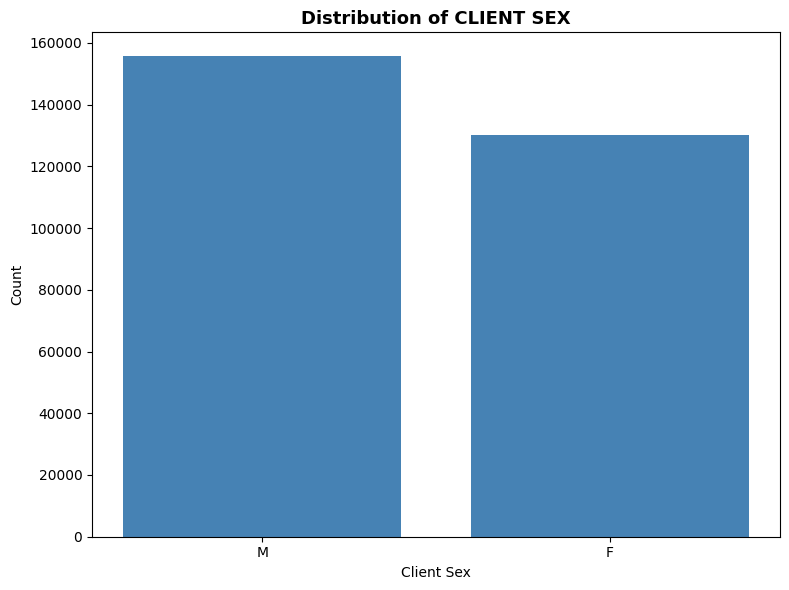

In [294]:
sex_counts = customer["CLIENT_SEX"].value_counts()

plt.figure(figsize = (8, 6))
plt.bar(sex_counts.index, sex_counts.values, color = "steelblue")
plt.title("Distribution of CLIENT SEX", fontsize = 13, weight = "bold")
plt.xlabel("Client Sex")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [295]:
group1 = customer.loc[(customer["DATE_OF_BIRTH"].isna()) & (customer["CLIENT_SEX"].isna())]
group1

,CUSTOMER_NUMBER,CLIENT_SEX,CLIENT_CREATE_DATE,DATE_OF_BIRTH,STAFF,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD
1372,886399,NaN,2019-02-20,NaT,N,2019-02-22,MYbank,N,SMART_OTP
2004,127792,NaN,2019-01-21,NaT,N,2019-01-28,MYbank,N,SMS
6388,263616,NaN,2019-11-12,NaT,N,2019-11-12,AUTO-JOB,N,SMART_OTP
8664,999266,NaN,2019-05-30,NaT,N,2019-05-30,AUTO-JOB,N,SMS
9082,851336,NaN,2019-03-13,NaT,N,2020-12-25,BRANCH,N,SMART_OTP
...,...,...,...,...,...,...,...,...,...
290083,607141,NaN,2019-04-08,NaT,N,NaT,NaN,NaN,NaN
290088,304883,NaN,2019-06-11,NaT,N,NaT,NaN,NaN,NaN
290091,146173,NaN,2019-08-16,NaT,N,NaT,NaN,NaN,NaN
290095,71678,NaN,2019-01-21,NaT,N,NaT,NaN,NaN,NaN


Quả đúng là những khách hàng thiếu CLIENT SEX -> thiếu DATE_OF_BIRTH. Tuy nhiên vẫn bị dư ra 6 khách hàng có CLIENT SEX nhưng thiếu DATE_OF_BIRTH. Cùng kiểm tra xem những khách hàng này có gì đặc biệt.

**Giả định**: Những khách hàng thiếu SEX/DOB là những khách hàng chưa register + verify

In [296]:
customer.loc[(customer["DATE_OF_BIRTH"].isna()) & (customer["CLIENT_SEX"].notnull())]

,CUSTOMER_NUMBER,CLIENT_SEX,CLIENT_CREATE_DATE,DATE_OF_BIRTH,STAFF,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD
54584,273643,F,2019-07-23,NaT,N,2019-08-10,MYbank,Y,SMART_OTP
74348,54959,M,2019-04-09,NaT,N,2020-11-17,BRANCH,N,SMART_OTP
161548,303228,M,2019-02-28,NaT,N,NaT,NaN,NaN,NaN
183544,635093,F,2019-02-12,NaT,N,NaT,NaN,NaN,NaN
192555,624064,M,2019-02-28,NaT,N,NaT,NaN,NaN,NaN
232730,81402,F,2019-08-21,NaT,N,NaT,NaN,NaN,NaN
233191,375114,F,2019-07-05,NaT,N,NaT,NaN,NaN,NaN
244372,35908,F,2019-12-11,NaT,N,NaT,NaN,NaN,NaN
245363,747431,M,2019-07-15,NaT,N,NaT,NaN,NaN,NaN
255156,600847,M,2019-12-09,NaT,N,NaT,NaN,NaN,NaN


In [297]:
group1.loc[group1.STAFF == "Y"]

,CUSTOMER_NUMBER,CLIENT_SEX,CLIENT_CREATE_DATE,DATE_OF_BIRTH,STAFF,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD


Những khách hàng thiếu thông tin về giới tính và dob ở đây đều không phải là nhân viên của ngân hàng, họ có thể là khách hàng đăng ký thông qua bên thứ ba/app/... hoặc cũng có thể do lỗi nhập liệu

In [298]:
group1.loc[group1.IB_REGISTER_DATE.isna()]

,CUSTOMER_NUMBER,CLIENT_SEX,CLIENT_CREATE_DATE,DATE_OF_BIRTH,STAFF,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD
159097,136398,NaN,2019-04-26,NaT,N,NaT,NaN,NaN,NaN
159112,534127,NaN,2019-03-16,NaT,N,NaT,NaN,NaN,NaN
159195,519318,NaN,2019-01-14,NaT,N,NaT,NaN,NaN,NaN
159202,958109,NaN,2019-01-15,NaT,N,NaT,NaN,NaN,NaN
159206,230149,NaN,2019-12-23,NaT,N,NaT,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
290083,607141,NaN,2019-04-08,NaT,N,NaT,NaN,NaN,NaN
290088,304883,NaN,2019-06-11,NaT,N,NaT,NaN,NaN,NaN
290091,146173,NaN,2019-08-16,NaT,N,NaT,NaN,NaN,NaN
290095,71678,NaN,2019-01-21,NaT,N,NaT,NaN,NaN,NaN


In [299]:
group1.loc[group1.IB_REGISTER_DATE.notna()]

,CUSTOMER_NUMBER,CLIENT_SEX,CLIENT_CREATE_DATE,DATE_OF_BIRTH,STAFF,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD
1372,886399,NaN,2019-02-20,NaT,N,2019-02-22,MYbank,N,SMART_OTP
2004,127792,NaN,2019-01-21,NaT,N,2019-01-28,MYbank,N,SMS
6388,263616,NaN,2019-11-12,NaT,N,2019-11-12,AUTO-JOB,N,SMART_OTP
8664,999266,NaN,2019-05-30,NaT,N,2019-05-30,AUTO-JOB,N,SMS
9082,851336,NaN,2019-03-13,NaT,N,2020-12-25,BRANCH,N,SMART_OTP
11029,738649,NaN,2019-01-25,NaT,N,2019-02-01,MYbank,N,SMART_OTP
21249,857201,NaN,2019-07-12,NaT,N,2019-07-13,AUTO-JOB,N,SMART_OTP
43158,572309,NaN,2019-05-06,NaT,N,2019-05-28,MYbank,N,SMS
55082,986512,NaN,2019-01-24,NaT,N,2019-03-26,MYbank,N,SMS
60955,665336,NaN,2019-06-27,NaT,N,2019-06-27,AUTO-JOB,N,SMART_OTP


Có 44 khách hàng dù thiếu cả CLIENT_SEX và DATE_OF_BIRTH nhưng vẫn đã đăng ký Internet Banking đầy đủ (có IB_REGISTER_DATE, EB_REGISTER_CHANNEL, SMS, VERIFY_METHOD). 

=> "Thiếu SEX/DOB" và "chưa đăng ký IB" là 2 khái niệm **độc lập**, không gộp chung thành 1 flag duy nhất

## 3.2. Xử lý DATE_OF_BIRTH bị lỗi định dạng (typo năm sinh)

Ở cell 19, sau khi convert sang datetime, số khách hàng có CLIENT_SEX nhưng thiếu DATE_OF_BIRTH tăng từ 6 lên 11. Nghi ngờ đây là lỗi parse do năm sinh bị nhập sai (typo), khiến pandas coerce thành NaT (Timestamp chỉ hỗ trợ năm trong khoảng 1677-2262).

Cần đọc lại raw string DATE_OF_BIRTH gốc (trước khi bị ghi đè ở cell 13) để kiểm tra.

In [300]:
# Đọc lại raw string DATE_OF_BIRTH từ file gốc để backup + kiểm tra lỗi định dạng
customer_raw_dob = pd.read_csv(
    "Data_Customer.csv",
    usecols = ["CUSTOMER_NUMBER", "DATE_OF_BIRTH"],
    dtype = {"DATE_OF_BIRTH": str}
).rename(columns = {"DATE_OF_BIRTH": "DOB_RAW_BACKUP"})

customer = customer.merge(customer_raw_dob, on = "CUSTOMER_NUMBER", how = "left")
customer[["CUSTOMER_NUMBER", "DATE_OF_BIRTH", "DOB_RAW_BACKUP"]].head()

,CUSTOMER_NUMBER,DATE_OF_BIRTH,DOB_RAW_BACKUP
0,639362,1996-01-01,1/1/1996 0:00
1,452440,1999-10-10,10/10/1999 0:00
2,326290,1996-06-29,6/29/1996 0:00
3,20802,1992-08-07,8/7/1992 0:00
4,114244,1973-10-15,10/15/1973 0:00


In [301]:
def extract_year(s):
    if pd.isna(s):
        return None
    m = re.match(r"(\d{4})-\d{2}-\d{2}", str(s))
    return int(m.group(1)) if m else None

customer["DOB_YEAR_RAW"] = customer["DOB_RAW_BACKUP"].apply(extract_year)

# Khoảng năm sinh hợp lý: 1920 - 2019 (năm cuối cùng của CLIENT_CREATE_DATE)
YEAR_MIN, YEAR_MAX = 1920, 2019

invalid_year_mask = customer["DOB_YEAR_RAW"].notna() & (
    (customer["DOB_YEAR_RAW"] < YEAR_MIN) | (customer["DOB_YEAR_RAW"] > YEAR_MAX)
)

print(f"Số dòng năm sinh bất thường (typo): {invalid_year_mask.sum()}")
customer.loc[invalid_year_mask, ["CUSTOMER_NUMBER", "CLIENT_SEX", "DOB_RAW_BACKUP", "IB_REGISTER_DATE", "VERIFY_METHOD"]]

Số dòng năm sinh bất thường (typo): 5


,CUSTOMER_NUMBER,CLIENT_SEX,DOB_RAW_BACKUP,IB_REGISTER_DATE,VERIFY_METHOD
54584,273643,F,0996-07-28 00:00:00,2019-08-10,SMART_OTP
74348,54959,M,1061-06-12 00:00:00,2020-11-17,SMART_OTP
161548,303228,M,0199-12-13 00:00:00,NaT,NaN
192555,624064,M,0199-12-26 00:00:00,NaT,NaN
245363,747431,M,1665-04-19 00:00:00,NaT,NaN


Có đúng 5 dòng năm sinh bất thường (VD: `0996-07-28`, `1061-06-12`...) — nhiều khả năng do gõ nhầm 1 chữ số. Trong đó **2/5** khách hàng đã đăng ký + verify IB (có thể ưu tiên đối chiếu thủ công sau này).

**Quyết định xử lý:** Coi các giá trị này là **không hợp lệ → set về missing**, đồng thời gắn flag riêng `DOB_INVALID_FORMAT` để phân biệt với trường hợp thiếu dữ liệu hoàn toàn, và giữ lại raw value gốc ở `DOB_raw_backup` để tra cứu lại sau nếu cần.

In [302]:
customer["DOB_INVALID_FORMAT"] = invalid_year_mask.astype(int)

# Set về NaT cho các dòng năm sinh bất thường
customer.loc[customer["DOB_INVALID_FORMAT"] == 1, "DATE_OF_BIRTH"] = pd.NaT

customer["DOB_INVALID_FORMAT"].value_counts()

DOB_INVALID_FORMAT
0    290218
1         5
Name: count, dtype: int64

## 3.3. Tạo flag missing tổng hợp + encode CLIENT_SEX

In [303]:
customer["SEX_MISSING"] = customer["CLIENT_SEX"].isna().astype(int)
customer["DOB_MISSING"] = customer["DATE_OF_BIRTH"].isna().astype(int)  # đã gồm cả raw-NaN lẫn invalid-format

# Flag tổng quát: khách hàng thiếu hồ sơ định danh (thiếu ít nhất 1 trong 2 SEX/DOB)
customer["IS_THIN_PROFILE"] = ((customer["SEX_MISSING"] == 1) | (customer["DOB_MISSING"] == 1)).astype(int)

# Encode CLIENT_SEX missing -> UNKNOWN (giữ làm 1 category riêng, không fill mode)
customer["CLIENT_SEX"] = customer["CLIENT_SEX"].fillna("UNKNOWN")

customer[["SEX_MISSING", "DOB_MISSING", "IS_THIN_PROFILE"]].sum()

SEX_MISSING        4283
DOB_MISSING        4294
IS_THIN_PROFILE    4294
dtype: int64

In [304]:
customer["CLIENT_SEX"].value_counts(dropna = False)

CLIENT_SEX
M          155636
F          130304
UNKNOWN      4283
Name: count, dtype: int64

## 3.4. Danh sách khách hàng cần đối chiếu thủ công

2 khách hàng có DOB lỗi định dạng nhưng đã register + verify IB đầy đủ — nên ưu tiên tra cứu lại hồ sơ gốc (CCCD/KYC) nếu có thể, thay vì loại bỏ hoàn toàn.

In [305]:
manual_review = customer.loc[
    (customer["DOB_INVALID_FORMAT"] == 1)
    & (customer["IB_REGISTER_DATE"].notna())
    & (customer["VERIFY_METHOD"].notna()),
    ["CUSTOMER_NUMBER", "CLIENT_SEX", "DOB_RAW_BACKUP", "CLIENT_CREATE_DATE", "IB_REGISTER_DATE", "VERIFY_METHOD"]
]

manual_review.to_csv("customer_dob_manual_review.csv", index = False)
manual_review

,CUSTOMER_NUMBER,CLIENT_SEX,DOB_RAW_BACKUP,CLIENT_CREATE_DATE,IB_REGISTER_DATE,VERIFY_METHOD
54584,273643,F,0996-07-28 00:00:00,2019-07-23,2019-08-10,SMART_OTP
74348,54959,M,1061-06-12 00:00:00,2019-04-09,2020-11-17,SMART_OTP


## 3.5. Tính AGE + rà soát outlier tuổi

In [306]:
customer["AGE_AT_CREATE"] = (customer["CLIENT_CREATE_DATE"] - customer["DATE_OF_BIRTH"]).dt.days / 365.25

print("--- AGE_AT_CREATE DESCRIPTION ---")
customer["AGE_AT_CREATE"].describe()

--- AGE_AT_CREATE DESCRIPTION ---


count    285929.000000
mean         34.620196
std          11.692115
min           0.002738
25%          25.861739
50%          32.260096
75%          41.056810
max         119.575633
Name: AGE_AT_CREATE, dtype: float64

In [307]:
# Đánh dấu outlier tuổi (<18 hoặc >100), CHƯA xử lý, để quyết định ngưỡng ở bước sau
customer["AGE_OUTLIER"] = 0
customer.loc[
    customer["AGE_AT_CREATE"].notna()
    & ((customer["AGE_AT_CREATE"] < 18) | (customer["AGE_AT_CREATE"] > 100)),
    "AGE_OUTLIER"
] = 1

print(f"Số khách hàng tuổi < 18: {(customer['AGE_AT_CREATE'] < 18).sum()}")
print(f"Số khách hàng tuổi > 100: {(customer['AGE_AT_CREATE'] > 100).sum()}")
customer["AGE_OUTLIER"].value_counts()

Số khách hàng tuổi < 18: 2239
Số khách hàng tuổi > 100: 50


AGE_OUTLIER
0    287934
1      2289
Name: count, dtype: int64

In [308]:
customer.head()

,CUSTOMER_NUMBER,CLIENT_SEX,CLIENT_CREATE_DATE,DATE_OF_BIRTH,STAFF,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD,DOB_RAW_BACKUP,DOB_YEAR_RAW,DOB_INVALID_FORMAT,SEX_MISSING,DOB_MISSING,IS_THIN_PROFILE,AGE_AT_CREATE,AGE_OUTLIER
0,639362,M,2019-04-23,1996-01-01,N,2019-04-23,BRANCH,Y,SMS,1/1/1996 0:00,NaN,0,0,0,0,23.307324,0
1,452440,M,2019-01-11,1999-10-10,N,2019-01-11,BRANCH,Y,SMART_OTP,10/10/1999 0:00,NaN,0,0,0,0,19.255305,0
2,326290,F,2019-05-27,1996-06-29,N,2019-05-27,BRANCH,Y,SMS,6/29/1996 0:00,NaN,0,0,0,0,22.907598,0
3,20802,M,2019-11-12,1992-08-07,N,2019-11-12,BRANCH,Y,SMART_OTP,8/7/1992 0:00,NaN,0,0,0,0,27.263518,0
4,114244,M,2019-03-29,1973-10-15,N,2019-03-29,BRANCH,N,SMS,10/15/1973 0:00,NaN,0,0,0,0,45.451061,0


/var/folders/b1/491xk5n932bfp5bf2vg1cfw40000gn/T/ipykernel_18030/796823280.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc = "upper left", frameon = False)


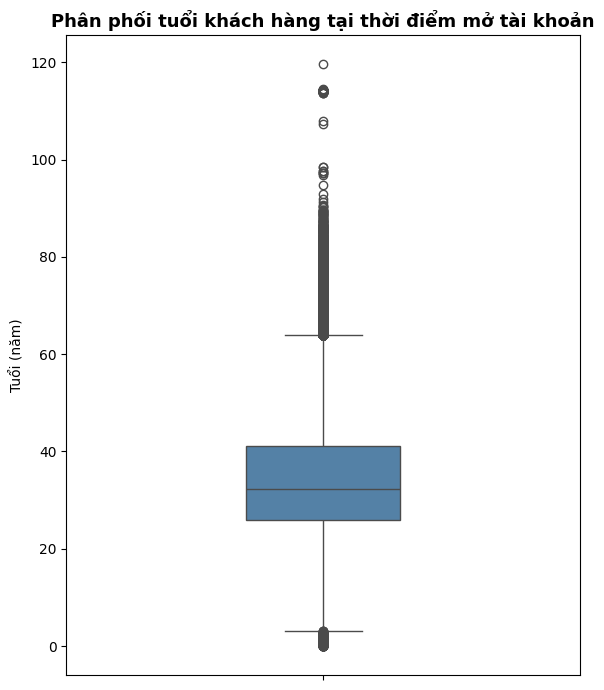

In [309]:
fig, ax = plt.subplots(figsize=(6, 7))

sns.boxplot(
    y = customer["AGE_AT_CREATE"],
    color = "steelblue",
    width = 0.3,
    ax = ax,
)

ax.set_title("Phân phối tuổi khách hàng tại thời điểm mở tài khoản", fontsize = 13, weight = "bold")
ax.set_ylabel("Tuổi (năm)")
ax.set_xlabel("")
ax.legend(loc = "upper left", frameon = False)
plt.tight_layout()
plt.show()

In [310]:
# Nhóm >100 tuổi: set về missing (nghi ngờ mạnh là placeholder ~1905)
suspect_default_mask = customer["AGE_AT_CREATE"] > 100
print("Số dòng bị set về missing (nghi placeholder):", suspect_default_mask.sum())

customer["DOB_SUSPECTED_DEFAULT"] = suspect_default_mask.astype(int)
customer.loc[suspect_default_mask, "DATE_OF_BIRTH"] = pd.NaT
customer.loc[suspect_default_mask, "AGE_AT_CREATE"] = None

# Cập nhật lại DOB_MISSING (đã gồm: raw NaN + invalid format + suspected default)
customer["DOB_MISSING"] = customer["DATE_OF_BIRTH"].isna().astype(int)
customer["IS_THIN_PROFILE"] = ((customer["SEX_MISSING"] == 1) | (customer["DOB_MISSING"] == 1)).astype(int)

# AGE_OUTLIER giờ chỉ còn phản ánh nhóm < 18 tuổi (nhóm > 100 tuổi đã thành NaN, tự động không còn bị flag)
customer["AGE_OUTLIER"] = 0
customer.loc[customer["AGE_AT_CREATE"].notna() & (customer["AGE_AT_CREATE"] < 18), "AGE_OUTLIER"] = 1

print("\nDOB_MISSING sau cùng:", customer["DOB_MISSING"].sum())
print("AGE_OUTLIER (chỉ còn nhóm <18):", customer["AGE_OUTLIER"].sum())
print("DOB_SUSPECTED_DEFAULT:", customer["DOB_SUSPECTED_DEFAULT"].sum())

Số dòng bị set về missing (nghi placeholder): 50

DOB_MISSING sau cùng: 4344
AGE_OUTLIER (chỉ còn nhóm <18): 2239
DOB_SUSPECTED_DEFAULT: 50


**TODO (bước sau):** quyết định ngưỡng xử lý AGE_OUTLIER (giữ nguyên/loại bỏ/set NaN cho AGE), rồi tiếp tục sang cột `STAFF`.

## 3.6. Xử lý STAFF

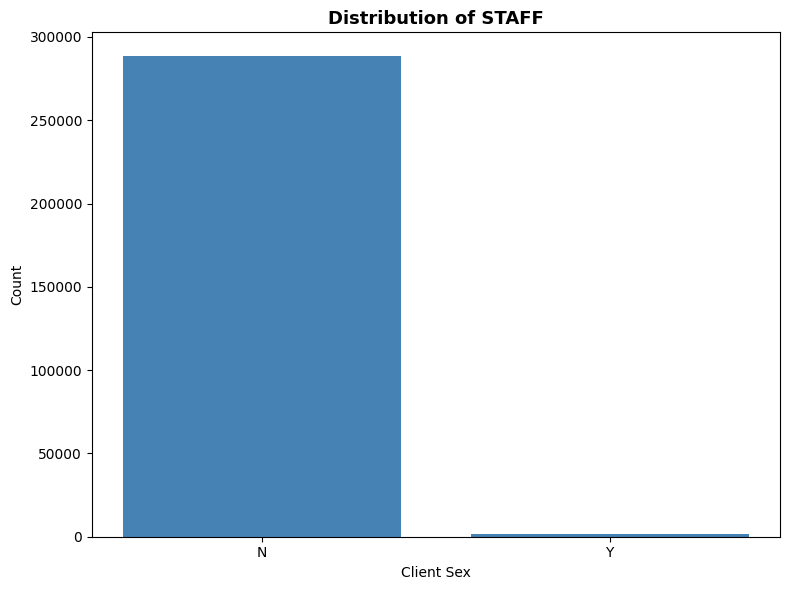

In [311]:
staff_counts = customer["STAFF"].value_counts()

plt.figure(figsize = (8, 6))
plt.bar(staff_counts.index, staff_counts.values, color = "steelblue")
plt.title("Distribution of STAFF", fontsize = 13, weight = "bold")
plt.xlabel("Client Sex")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Dữ liệu bị mất cân bằng
- STAFF = Y chiểm tỉ lệ rất ít --> Cân suy nghĩ trước khi vào giai đoạn modeling
- Nhân viên ngân hàng thường có hành vi tài chính khác biệt (ưu đãi nội bộ, sản phẩm đặc thù) nên có thể không phản ánh đúng hành vi của những khác hàng thông thường

Có 2 hướng như sau:
1. Giữ lại STAFF bình thường để model tự học sự khác biệt
2. Loại STAFF = Y ra khỏi tập train (Vẫn giữ dataset gốc, chỉ đổi filter lúc train)


Tuy nhiên cách chia còn phụ thuộc vào mục tiêu cuối, có thể là dự đoán cho khách hàng external

In [312]:
customer = pd.get_dummies(customer, columns = ["STAFF"], drop_first = True, dtype = int)
customer = customer.rename(columns = {"STAFF_Y": "STAFF"})
customer

,CUSTOMER_NUMBER,CLIENT_SEX,CLIENT_CREATE_DATE,DATE_OF_BIRTH,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD,DOB_RAW_BACKUP,DOB_YEAR_RAW,DOB_INVALID_FORMAT,SEX_MISSING,DOB_MISSING,IS_THIN_PROFILE,AGE_AT_CREATE,AGE_OUTLIER,DOB_SUSPECTED_DEFAULT,STAFF
0,639362,M,2019-04-23,1996-01-01,2019-04-23,BRANCH,Y,SMS,1/1/1996 0:00,NaN,0,0,0,0,23.307324,0,0,0
1,452440,M,2019-01-11,1999-10-10,2019-01-11,BRANCH,Y,SMART_OTP,10/10/1999 0:00,NaN,0,0,0,0,19.255305,0,0,0
2,326290,F,2019-05-27,1996-06-29,2019-05-27,BRANCH,Y,SMS,6/29/1996 0:00,NaN,0,0,0,0,22.907598,0,0,0
3,20802,M,2019-11-12,1992-08-07,2019-11-12,BRANCH,Y,SMART_OTP,8/7/1992 0:00,NaN,0,0,0,0,27.263518,0,0,0
4,114244,M,2019-03-29,1973-10-15,2019-03-29,BRANCH,N,SMS,10/15/1973 0:00,NaN,0,0,0,0,45.451061,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290218,174454,F,2019-07-08,1997-12-09,NaT,NaN,NaN,NaN,12/9/1997 0:00,NaN,0,0,0,0,21.577002,0,0,0
290219,195828,F,2019-10-10,1999-06-13,NaT,NaN,NaN,NaN,6/13/1999 0:00,NaN,0,0,0,0,20.325804,0,0,0
290220,234465,M,2019-01-23,1974-12-10,NaT,NaN,NaN,NaN,12/10/1974 0:00,NaN,0,0,0,0,44.120465,0,0,0
290221,119456,M,2019-04-09,1995-06-15,NaT,NaN,NaN,NaN,6/15/1995 0:00,NaN,0,0,0,0,23.816564,0,0,0


## 3.6. REGISTER DATE + CHANNEL, SMS, VERIFY METHOD

In [313]:
group2 = customer[["IB_REGISTER_DATE", "EB_REGISTER_CHANNEL", "SMS", "VERIFY_METHOD"]]
group2.sample(10)

,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD
40176,2020-01-10,MYbank,Y,SMART_OTP
265632,NaT,NaN,NaN,NaN
4433,2019-08-10,BRANCH,Y,SMART_OTP
181032,NaT,NaN,NaN,NaN
28732,2019-10-03,BRANCH,Y,SMART_OTP
125067,2020-01-30,BRANCH,N,SMART_OTP
273368,NaT,NaN,NaN,NaN
10815,2019-01-11,BRANCH,N,SMS
12257,2020-08-10,MYbank,Y,SMART_OTP
76927,2019-12-26,BRANCH,Y,SMART_OTP


In [314]:
group2.isna().sum()

IB_REGISTER_DATE       131248
EB_REGISTER_CHANNEL    131248
SMS                    131248
VERIFY_METHOD          131276
dtype: int64

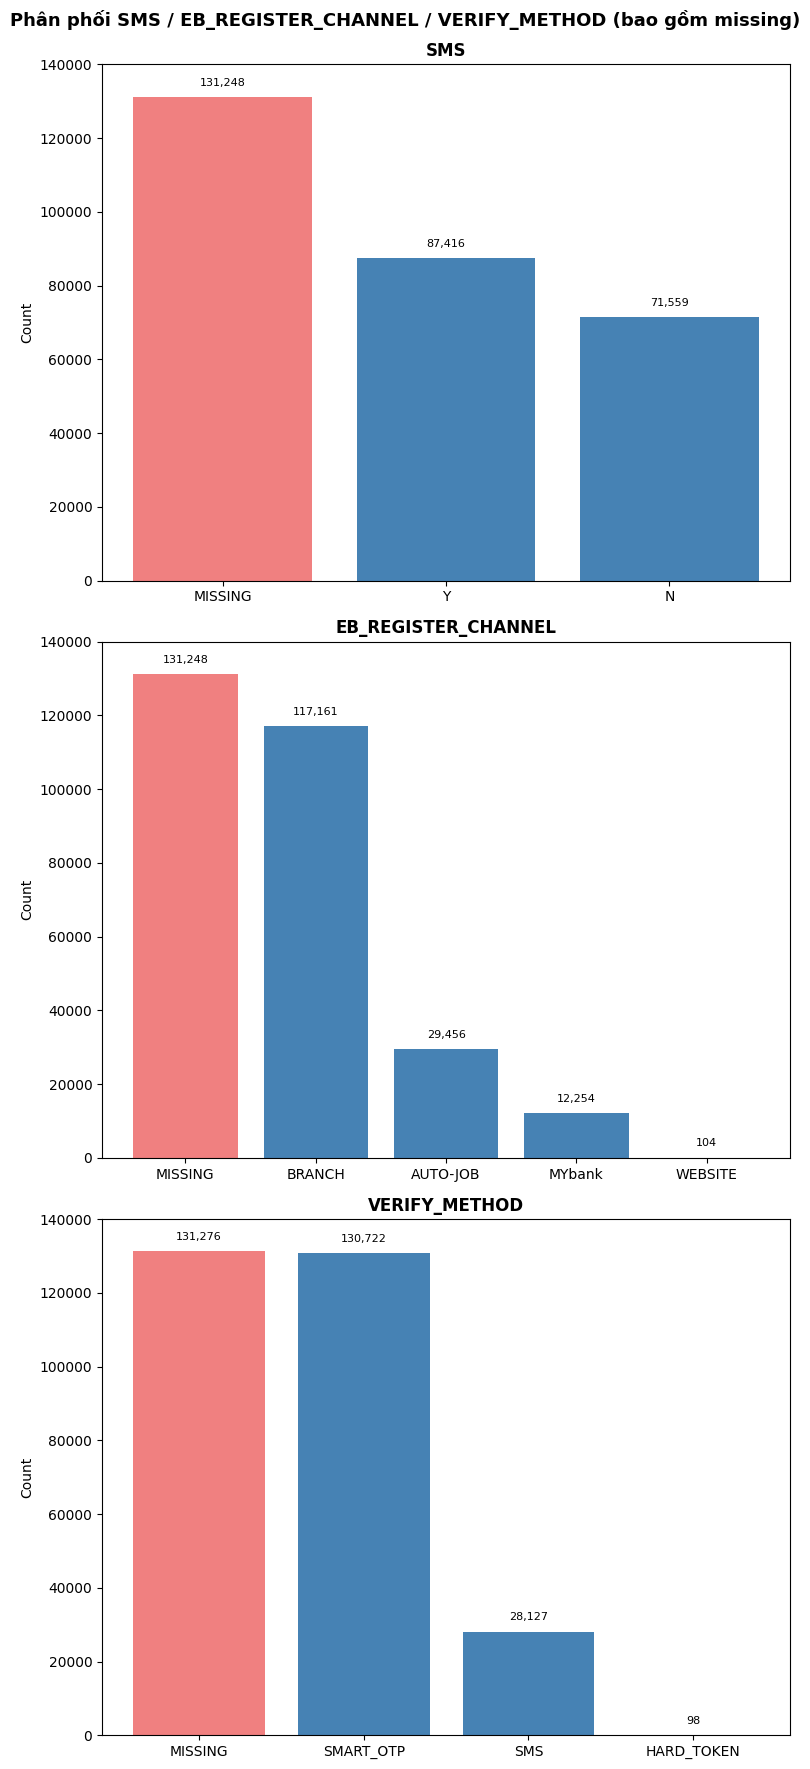

In [315]:
cols = ["SMS", "EB_REGISTER_CHANNEL", "VERIFY_METHOD"]

fig, axes = plt.subplots(3, 1, figsize = (8, 18))

for ax, col in zip(axes, cols):
    counts = customer[col].value_counts(dropna = False)
    labels = ["MISSING" if pd.isna(idx) else str(idx) for idx in counts.index]
    colors = ["lightcoral" if lbl == "MISSING" else "steelblue" for lbl in labels]
    ax.bar(labels, counts.values, color = colors)
    ax.set_title(col, fontsize = 12, weight = "bold")
    ax.set_ylabel("Count")
    ax.set_ylim(0, 140000)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 3000, f"{v:,}", ha = "center", fontsize = 8)

plt.suptitle("Phân phối SMS / EB_REGISTER_CHANNEL / VERIFY_METHOD (bao gồm missing)", fontsize = 13, weight = "bold")
plt.tight_layout(rect = [0, 0, 1, 0.99])
plt.show()

Những khách hàng đồng thời thiếu 4 nhóm cột này ta giả định là khách hàng chưa register --> fill NaN bằng NOT_REGISTERED

In [316]:
customer["EB_REGISTER_CHANNEL"] = customer["EB_REGISTER_CHANNEL"].replace(np.nan, "NOT_REGISTERED")
customer["SMS"] = customer["SMS"].replace(np.nan, "NOT_REGISTERED")
customer["VERIFY_METHOD"] = customer["VERIFY_METHOD"].replace(np.nan, "NOT_REGISTERED")
customer["HAS_IB_ACCOUNT"] = customer["IB_REGISTER_DATE"].notna().astype(int)
customer["DAYS_TO_REGISTER"] = (customer["IB_REGISTER_DATE"] - customer["CLIENT_CREATE_DATE"]).dt.days

group2 = customer[["IB_REGISTER_DATE", "EB_REGISTER_CHANNEL", "SMS", "VERIFY_METHOD", "HAS_IB_ACCOUNT", "DAYS_TO_REGISTER"]]
group2.sample(10)

,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD,HAS_IB_ACCOUNT,DAYS_TO_REGISTER
15832,2019-08-30,BRANCH,Y,SMART_OTP,1,1.0
83156,2019-08-27,AUTO-JOB,Y,SMART_OTP,1,116.0
287586,NaT,NOT_REGISTERED,NOT_REGISTERED,NOT_REGISTERED,0,NaN
157453,2019-09-18,BRANCH,N,SMART_OTP,1,0.0
109799,2019-04-26,BRANCH,N,SMS,1,0.0
138024,2019-11-15,BRANCH,Y,SMART_OTP,1,0.0
182581,NaT,NOT_REGISTERED,NOT_REGISTERED,NOT_REGISTERED,0,NaN
57138,2019-05-16,BRANCH,Y,SMART_OTP,1,1.0
270336,NaT,NOT_REGISTERED,NOT_REGISTERED,NOT_REGISTERED,0,NaN
44181,2019-11-29,BRANCH,N,SMART_OTP,1,0.0


In [317]:
customer.isna().any()

CUSTOMER_NUMBER          False
CLIENT_SEX               False
CLIENT_CREATE_DATE       False
DATE_OF_BIRTH             True
IB_REGISTER_DATE          True
EB_REGISTER_CHANNEL      False
SMS                      False
VERIFY_METHOD            False
DOB_RAW_BACKUP            True
DOB_YEAR_RAW              True
DOB_INVALID_FORMAT       False
SEX_MISSING              False
DOB_MISSING              False
IS_THIN_PROFILE          False
AGE_AT_CREATE             True
AGE_OUTLIER              False
DOB_SUSPECTED_DEFAULT    False
STAFF                    False
HAS_IB_ACCOUNT           False
DAYS_TO_REGISTER          True
dtype: bool

Về số lượng khách hàng thiếu verify method đang nhiều hơn so với 3 cột kia là 28 khách hàng. Vậy 28 khách hàng này có gì đặc biệt?

In [318]:
group28 = customer.loc[
    (customer["HAS_IB_ACCOUNT"] == 1) & (customer["VERIFY_METHOD"] == "NOT_REGISTERED")
]

print("Số lượng:", len(group28))
print(group28["EB_REGISTER_CHANNEL"].value_counts(), "\n")
print(group28["SMS"].value_counts(), "\n")
print(group28["IB_REGISTER_DATE"].value_counts(), "\n")
print(group28["HAS_IB_ACCOUNT"].value_counts(), "\n")
print(group28["DAYS_TO_REGISTER"].sort_values(ascending = True))

Số lượng: 28
EB_REGISTER_CHANNEL
BRANCH    28
Name: count, dtype: int64 

SMS
Y    26
N     2
Name: count, dtype: int64 

IB_REGISTER_DATE
2019-09-16    14
2019-10-08     7
2019-06-14     5
2019-06-19     1
2019-06-13     1
Name: count, dtype: int64 

HAS_IB_ACCOUNT
1    28
Name: count, dtype: int64 

28563      0.0
158687     1.0
137455     1.0
18232      2.0
23090      2.0
90178      3.0
118786     6.0
118884     6.0
98052      6.0
87222      6.0
122536     6.0
33197      6.0
115099     6.0
6210       7.0
117419    11.0
139681    11.0
120490    11.0
4817      11.0
111527    11.0
107604    11.0
107580    11.0
139834    11.0
71332     11.0
70360     11.0
53939     11.0
42586     11.0
114125    11.0
104268    11.0
Name: DAYS_TO_REGISTER, dtype: float64


In [319]:
group28

,CUSTOMER_NUMBER,CLIENT_SEX,CLIENT_CREATE_DATE,DATE_OF_BIRTH,IB_REGISTER_DATE,EB_REGISTER_CHANNEL,SMS,VERIFY_METHOD,DOB_RAW_BACKUP,DOB_YEAR_RAW,DOB_INVALID_FORMAT,SEX_MISSING,DOB_MISSING,IS_THIN_PROFILE,AGE_AT_CREATE,AGE_OUTLIER,DOB_SUSPECTED_DEFAULT,STAFF,HAS_IB_ACCOUNT,DAYS_TO_REGISTER
4817,910348,M,2019-09-05,1994-12-09,2019-09-16,BRANCH,Y,NOT_REGISTERED,12/9/1994 0:00,NaN,0,0,0,0,24.739220,0,0,0,1,11.0
6210,133728,M,2019-06-12,1970-07-01,2019-06-19,BRANCH,Y,NOT_REGISTERED,7/1/1970 0:00,NaN,0,0,0,0,48.947296,0,0,0,1,7.0
18232,783533,F,2019-06-12,1992-06-16,2019-06-14,BRANCH,N,NOT_REGISTERED,6/16/1992 0:00,NaN,0,0,0,0,26.986995,0,0,0,1,2.0
23090,231398,M,2019-06-12,1992-07-29,2019-06-14,BRANCH,Y,NOT_REGISTERED,7/29/1992 0:00,NaN,0,0,0,0,26.869268,0,0,0,1,2.0
28563,444910,M,2019-06-13,1996-06-27,2019-06-13,BRANCH,Y,NOT_REGISTERED,6/27/1996 0:00,NaN,0,0,0,0,22.959617,0,0,0,1,0.0
33197,963051,F,2019-10-02,1988-01-01,2019-10-08,BRANCH,Y,NOT_REGISTERED,1/1/1988 0:00,NaN,0,0,0,0,31.750856,0,0,0,1,6.0
42586,515756,M,2019-09-05,1981-04-20,2019-09-16,BRANCH,Y,NOT_REGISTERED,4/20/1981 0:00,NaN,0,0,0,0,38.376454,0,0,0,1,11.0
53939,317296,M,2019-09-05,1995-03-02,2019-09-16,BRANCH,Y,NOT_REGISTERED,3/2/1995 0:00,NaN,0,0,0,0,24.511978,0,0,0,1,11.0
70360,912704,M,2019-09-05,1977-01-01,2019-09-16,BRANCH,Y,NOT_REGISTERED,1/1/1977 0:00,NaN,0,0,0,0,42.674880,0,0,0,1,11.0
71332,598266,M,2019-09-05,1993-04-24,2019-09-16,BRANCH,Y,NOT_REGISTERED,4/24/1993 0:00,NaN,0,0,0,0,26.365503,0,0,0,1,11.0


Nhận xét: 28 khách hàng này đều đã:
- Có tài khoản
- Đều đăng ký tại branch
- Số ngày từ khi đăng ký đến khi tạo tài khoản không quá lâu (0 - 11 ngày)
- Hầu hết chọn nhận tin nhắn qua SMS
- Register date giới hạn trong 5 ngày

--> Có thể đây là lỗi typo/quy trình của chi nhánh hoặc lý do chưa biết của khách hàng dẫn đến chưa thẻ xác thực.
--> Hướng xử lý: Để lại 28 khách hàng này tới khi merge các bảng thì sẽ trích xuất thêm các đặc trưng khác.

In [320]:
# Tạo thêm biến này để khi marge các ta tiện theo dõi
customer["VERIFY_METHOD_ANOMALY"] = (
    customer["IB_REGISTER_DATE"].notna() & customer["VERIFY_METHOD"].isna()
).astype(int)

# Tách ra luôn 1 bảng những khách hàng thiếu/lỗi thông tin
data_quality_flags = customer[[
    "CUSTOMER_NUMBER", "SEX_MISSING", "DOB_MISSING", "IS_THIN_PROFILE",
    "DOB_INVALID_FORMAT", "DOB_SUSPECTED_DEFAULT", "AGE_OUTLIER",
    "STAFF", "HAS_IB_ACCOUNT", "VERIFY_METHOD_ANOMALY"
]]

# Xem nhanh khách hàng dính nhiều vấn đề cùng lúc (đáng nghi nhất)
data_quality_flags["TOTAL_FLAGS"] = data_quality_flags.drop(columns = "CUSTOMER_NUMBER").sum(axis = 1)
data_quality_flags.sort_values("TOTAL_FLAGS", ascending = False).head(10)

/var/folders/b1/491xk5n932bfp5bf2vg1cfw40000gn/T/ipykernel_18030/480640210.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_quality_flags["TOTAL_FLAGS"] = data_quality_flags.drop(columns = "CUSTOMER_NUMBER").sum(axis = 1)


,CUSTOMER_NUMBER,SEX_MISSING,DOB_MISSING,IS_THIN_PROFILE,DOB_INVALID_FORMAT,DOB_SUSPECTED_DEFAULT,AGE_OUTLIER,STAFF,HAS_IB_ACCOUNT,VERIFY_METHOD_ANOMALY,TOTAL_FLAGS
69603,605585,1,1,1,0,0,0,0,1,0,4
69464,222953,1,1,1,0,0,0,0,1,0,4
81708,679979,0,1,1,0,1,0,0,1,0,4
54584,273643,0,1,1,1,0,0,0,1,0,4
25642,219341,0,1,1,0,1,0,0,1,0,4
139597,871859,1,1,1,0,0,0,0,1,0,4
74366,904721,1,1,1,0,0,0,0,1,0,4
94014,601299,0,1,1,0,1,0,0,1,0,4
125579,65217,1,1,1,0,0,0,0,1,0,4
92829,926625,0,1,1,0,1,0,0,1,0,4


In [321]:
customer.to_csv("customer_clean.csv", index=False)
print(f"Đã lưu: customer_clean.csv | Shape: {customer.shape}")

Đã lưu: customer_clean.csv | Shape: (290223, 21)
